In [279]:
import pandas as pd

In [280]:
df = pd.read_csv('credit_risk_dataset.csv')

In [281]:
df.shape

(32581, 12)

In [282]:
df = df.drop_duplicates()

In [283]:
df.shape

(32416, 12)

In [284]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [285]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  object 
 3   person_emp_length           31529 non-null  float64
 4   loan_intent                 32416 non-null  object 
 5   loan_grade                  32416 non-null  object 
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               29321 non-null  float64
 8   loan_status                 32416 non-null  int64  
 9   loan_percent_income         32416 non-null  float64
 10  cb_person_default_on_file   32416 non-null  object 
 11  cb_person_cred_hist_length  32416 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


In [286]:
df['cb_person_default_on_file'].unique()

array(['Y', 'N'], dtype=object)

In [287]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,31529.00000,32416.000000,29321.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.79051,9593.845632,11.017265,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.14549,6322.730241,3.241680,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.00000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.00000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.00000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.00000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [288]:
df = df[df['person_age'] < 90]
df = df[df['loan_int_rate'] < 20]

In [289]:
df.shape

(29243, 12)

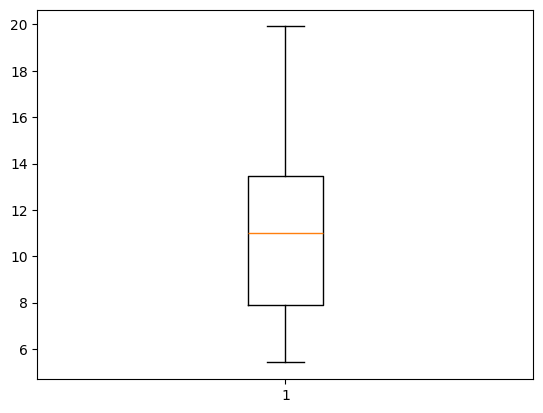

In [290]:
import matplotlib.pyplot as plt

plt.boxplot(df['loan_int_rate'])# need modification
plt.show()

In [291]:
df.isnull().sum()

person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             819
loan_intent                     0
loan_grade                      0
loan_amnt                       0
loan_int_rate                   0
loan_status                     0
loan_percent_income             0
cb_person_default_on_file       0
cb_person_cred_hist_length      0
dtype: int64

In [292]:
# import numpy as np
# df['person_emp_length'] = df['person_emp_length'].replace([np.inf, -np.inf], 0)
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())


In [293]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [294]:
df.shape

(29243, 12)

In [295]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [296]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [297]:
X = df.drop('loan_status',axis=1)
y = df['loan_status']

In [298]:
y.value_counts()

loan_status
0    22858
1     6385
Name: count, dtype: int64

In [299]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [300]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

scale_col = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

cat_col = ['person_home_ownership','loan_intent','cb_person_default_on_file','loan_grade']



preprocessor = ColumnTransformer(transformers=[
    ('ss', StandardScaler(), scale_col),
    ('encode', OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False), cat_col),
], remainder='passthrough')

In [301]:
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

In [302]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train_pre, y_train)

In [306]:
y_train.value_counts()

loan_status
1    16001
0    16001
Name: count, dtype: int64

In [307]:
X_train.shape

(32002, 22)

In [309]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix, classification_report

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test_pre)
y_pred_train = lr.predict(X_train)

print('train')
print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


train
0.7974501593650397
0.7758265108430723
[[13106  2895]
 [ 3587 12414]]
test
0.8134047646187165
0.791231732776618
[[5620 1237]
 [ 400 1516]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      6857
           1       0.55      0.79      0.65      1916

    accuracy                           0.81      8773
   macro avg       0.74      0.81      0.76      8773
weighted avg       0.85      0.81      0.82      8773



In [310]:
from sklearn.svm import SVC


svc = SVC()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test_pre)
y_pred_train = svc.predict(X_train)

print('train')
print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


train
0.8680082494844072
0.8014499093806637
[[14954  1047]
 [ 3177 12824]]
test
0.8937649606747977
0.7635699373695198
[[6378  479]
 [ 453 1463]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      6857
           1       0.75      0.76      0.76      1916

    accuracy                           0.89      8773
   macro avg       0.84      0.85      0.85      8773
weighted avg       0.89      0.89      0.89      8773



In [311]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_estimators=101,max_depth=3)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test_pre)
y_pred_train = rf.predict(X_train)

print('train')
print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


train
0.8096368976938941
0.7308918192612962
[[14215  1786]
 [ 4306 11695]]
test
0.8539838139746951
0.7275574112734864
[[6098  759]
 [ 522 1394]]
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      6857
           1       0.65      0.73      0.69      1916

    accuracy                           0.85      8773
   macro avg       0.78      0.81      0.80      8773
weighted avg       0.86      0.85      0.86      8773



In [312]:
from xgboost import XGBClassifier


xg = XGBClassifier(n_estimators=101,max_depth=3)
xg.fit(X_train, y_train)
y_pred = xg.predict(X_test_pre)
y_pred_train = xg.predict(X_train)

print('train')
print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


train
0.9459721267420786
0.9075057808886945
[[15752   249]
 [ 1480 14521]]
test
0.9262509973783198
0.7275574112734864
[[6732  125]
 [ 522 1394]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      6857
           1       0.92      0.73      0.81      1916

    accuracy                           0.93      8773
   macro avg       0.92      0.85      0.88      8773
weighted avg       0.93      0.93      0.92      8773



In [313]:
from sklearn.naive_bayes import GaussianNB


naive = GaussianNB(priors=[0.5,0.5])
naive.fit(X_train, y_train)
y_pred = naive.predict(X_test_pre)
y_pred_train = naive.predict(X_train)

print('train')
print(accuracy_score(y_train, y_pred_train))
print(recall_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

print('test')
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


train
0.6407099556277732
0.31235547778263856
[[15506   495]
 [11003  4998]]
test
0.8273110680496979
0.319937369519833
[[6645  212]
 [1303  613]]
              precision    recall  f1-score   support

           0       0.84      0.97      0.90      6857
           1       0.74      0.32      0.45      1916

    accuracy                           0.83      8773
   macro avg       0.79      0.64      0.67      8773
weighted avg       0.82      0.83      0.80      8773

